In [78]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
import pandas as pd
import numpy as np
import warnings
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import nltk
from nltk.tokenize import word_tokenize
nltk.download('punkt_tab')

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/jupyter-238502/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

# 1. Frame the problem
Using the customer description, Define the problem your trying to solve in your own words (remember this is not technial but must be specific so the customer understands the project

We wish to determine whether a given email is spam, unimportant and unwanted, or ham, something that the recipient actually cares about, using its contents. We will train a model on an archive of emails whose status as spam or ham is already known in order to solve this problem.

# 2. Get the Data 
Define how you recieved the data (provided, gathered..)

We were provided a folder containing each email in the training set in a separate text file, with the spam emails being indicated as such via the name of the text files. When we actually use this data, we will later load it into a dataframe.

# 3. Explore the Data
Gain insights into the data you have from step 2, making sure to identify any bias

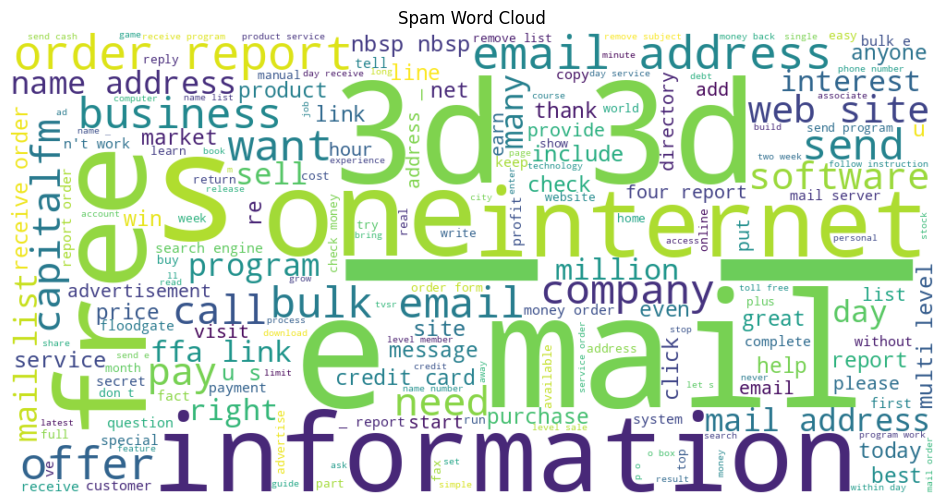

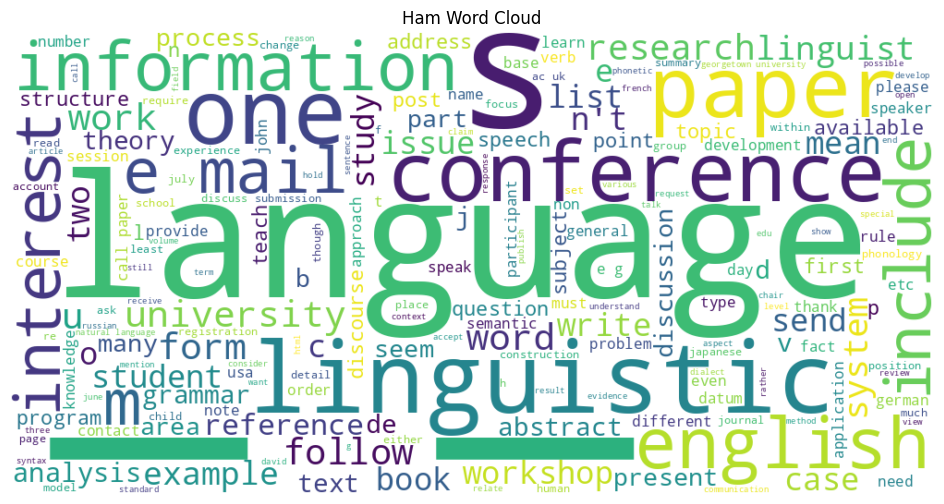

In [79]:
df = pd.DataFrame(columns=['Text', 'Spam'])
for email in os.listdir('email_archive'):
    if len(email) >= 4 and email[-4:] == '.txt':
        with open(os.path.join('email_archive', email)) as f:
            df.loc[len(df)] = [f.read(), email[:3] == 'spm']
    # Load the data to a dataframe

spam_text = ' '.join(df[df['Spam']]['Text'].astype(str))
ham_text = ' '.join(df[~df['Spam']]['Text'].astype(str))
spam_text = spam_text.replace('Subject: ', '')
ham_text = ham_text.replace('Subject: ', '')
    # Create one aggregated string out of both the spam and ham emails

wordcloud_spam = WordCloud(width=1000, height=500, background_color='white').generate(spam_text)
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_spam, interpolation='bilinear')
plt.axis('off')
plt.title("Spam Word Cloud")
plt.show()
wordcloud_ham = WordCloud(width=1000, height=500, background_color='white').generate(ham_text)
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_ham, interpolation='bilinear')
plt.axis('off')
plt.title("Ham Word Cloud")
plt.show()
    # Create and display word clouds

Initially, I was biased to believe that spam and ham emails would be difficult to distinguish based on basic features alone, seeing as spam emails would likely be designed to not be obviously spam. However, creating the word clouds showed that the most common words in both emails were noticably different. Common words in spam emails adhering to a common theme include "free", "order", "business", and "offer", whereas some examples from the ham emails include "language", "information", "conference", and "paper". These trends suggest that we may want to utilize a tool that can look at the individual words within an email, such as a tokenizer.

More trends we noticed just by opening some of the emails manually is that spam emails tend to be longer than ham emails, and also that ham emails tend to have unusual patterns of special characters. The former suggests creating an attribute for message length, and the latter suggets that it may be helpful to try to measure the use of special characters through some attribute.

# 4.Prepare the Data


Apply any data transformations and explain what and why


In [77]:
df = pd.DataFrame(columns=['Text', 'Spam'])
for email in os.listdir('email_archive'):
    if len(email) >= 4 and email[-4:] == '.txt':
        with open(os.path.join('email_archive', email)) as f:
            df.loc[len(df)] = [f.read(), email[:3] == 'spm']
            if (email[:3] == 'spm') != (email[:3] == 'spm'):
                print(email)
df['Subject'] = df['Text'].apply(lambda text: text.split('\n')[0][len('Subject: '):])
df['Body'] = df['Text'].apply(lambda text: text.split('\n')[2])
df.drop('Text', axis=1, inplace=True)
    # Separate subject from body

df['SubjectLength'] = df['Subject'].apply(len)
df['BodyLength'] = df['Body'].apply(len)
    # Create attributes for length

df['SubjectTokens'] = df['Subject'].apply(word_tokenize)
df['BodyTokens'] = df['Body'].apply(word_tokenize)
    # Tokenize body of emails

print(df.head(5))

    Spam                                         Subject  \
0  False  wkshp : * early * - e ( = ) uralic interaction   
1  False             job announcement - academium sinica   
2  False                 knowledge language bibliography   
3   True                                  service update   
4  False                                job announcement   

                                                Body  SubjectLength  \
0  organize combination colloquium work seminar p...             46   
1  job announcement institute history philology ,...             35   
2  association language awareness knowledge langu...             31   
3  due significant rapid policy change recently i...             14   
4  job announcement department foreign language l...             16   

   BodyLength                                      SubjectTokens  \
0        1917  [wkshp, :, *, early, *, -, e, (, =, ), uralic,...   
1        1339          [job, announcement, -, academium, sinica]   
2       

After loading all of our email data into a dataframe, since all emails have a clear subject and body we separate these into two separate attributes. Since we already noted that length would be important, we created attributes for the length of both the subject and body of the email. Finally, we tokenized the content of the emails so that when we model the data we have easy to work with tokens.

We note that while preparing the data, we should probably try to manually extract features that we think will be helpful (like body length) even if they are available through other features, because it may be hard for the model to extract this data on its own.

# 5. Model the data
Using selected ML models, experment with your choices and describe your findings. Finish by selecting a Model to continue with


0.49800796812749004


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
0.4302788844621514


0.3904382470119522


0.4820717131474104


# 6. Fine Tune the Model

With the select model descibe the steps taken to acheve the best rusults possiable 


0.5059760956175299


# 7. Present
In a customer faceing Document provide summery of finding and detail approach taken


# 8. Launch the Model System
Define your production run code, This should be self susficent and require only your model pramaters 


Not Purchase
